/tmp/ipykernel_27456/2357813173.py:59: RuntimeWarning: invalid value encountered in divide
  dyspec_norm[:, j] = (dyspec[:, j] - Imin) / (Imax - Imin) * 255
/tmp/ipykernel_27456/2357813173.py:59: RuntimeWarning: invalid value encountered in cast
  dyspec_norm[:, j] = (dyspec[:, j] - Imin) / (Imax - Imin) * 255


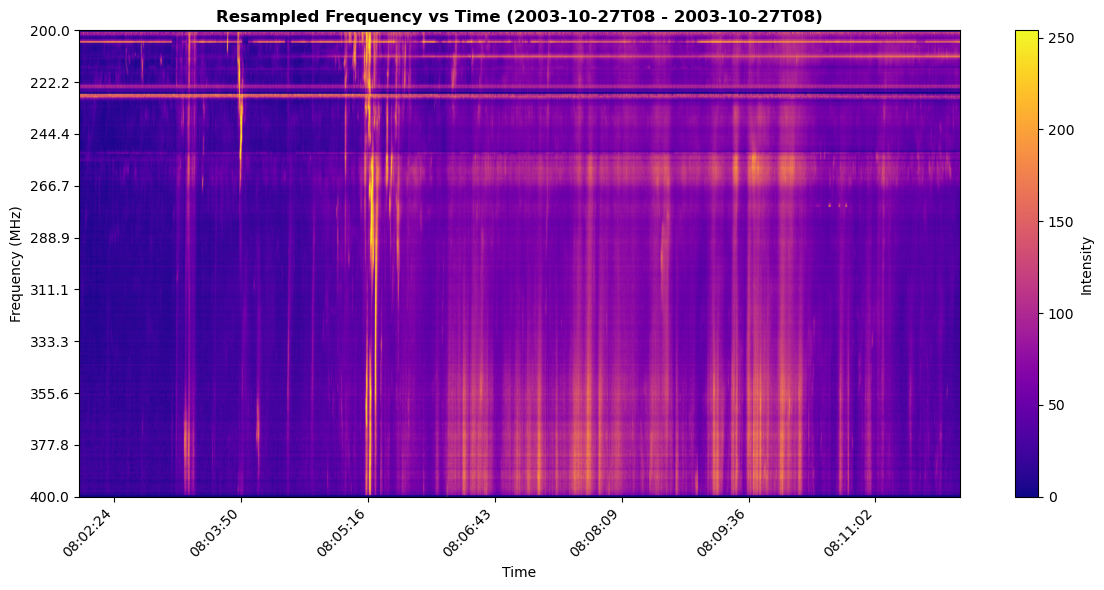

In [1]:
import matplotlib.dates as mdates
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.ndimage
import detectRadioburst_OSRA as drb

# Set file name and other initializations as before
fname = "/net/lyot/scratch3/vocks/OSRA/2003/CD_300/031027_300.roh"

(dyspec,t_fits,f_fits,)  = drb.read_osraf2(fname)
#(dyspec,f_fits) =  drb.cut_low(dyspec,f_fits,f_low_cut_val=30)
# Define the frequency array for f2
f2 = 400.0 - np.array(range(256)) * 200.0 / 255.0
f_fits = f2

# Simulate file size and stats
file_stats = os.stat(fname)
a1 = int(file_stats.st_size / 1040 + 0.5)

# Create a dummy start time
dummy_start = np.datetime64('2025-02-01T15:23:15.00')
t_fits = dummy_start + np.linspace(0, 1, a1).astype('timedelta64[D]')

# Initialize the spectrum array for f2 range only
dyspec = np.zeros((a1, 256), dtype=np.ubyte)

# Simulate reading the file
file = open(fname, "rb")
for i in range(a1):
    data_chunk = file.read(1040)
    np_data_chunk = np.frombuffer(data_chunk, dtype=np.uint8)
    year = int(np_data_chunk[0] / 16) * 10 + (np_data_chunk[0] & 15)
    if year > 50:
        year = year + 1900
    else:
        year = year + 2000

    # Extract time information
    month = int(np_data_chunk[1] / 16) * 10 + (np_data_chunk[1] & 15)
    day = int(np_data_chunk[2] / 16) * 10 + (np_data_chunk[2] & 15)
    hour = int(np_data_chunk[3] / 16) * 10 + (np_data_chunk[3] & 15)
    minute = int(np_data_chunk[4] / 16) * 10 + (np_data_chunk[4] & 15)
    second = int(np_data_chunk[5] / 16) * 10 + (np_data_chunk[5] & 15)
    microsecond = 100000 * np_data_chunk[6]

    t_fits[i] = datetime.datetime(year, month, day, hour, minute, second, microsecond)
    # Only take the relevant part of the data chunk for f2
    dyspec[i, :] = np_data_chunk[272: 528]  # Adjust the slice to match the f2 range

file.close()

# Normalize the data
dyspec_norm = np.zeros((a1, 256), dtype=np.ubyte)
for j in range(256):
    Imax = np.amax(dyspec[:, j])
    Imin = np.amin(dyspec[:, j])
    dyspec_norm[:, j] = (dyspec[:, j] - Imin) / (Imax - Imin) * 255

# Transpose the normalized data
dyspec_norm = dyspec_norm.T

# Define new frequency range (400 MHz to 200 MHz)
new_frequencies = np.linspace(400, 200, 1000)
target_steps = 5000

# Define the start and end time for the entire dataset
start_time = np.datetime64('2003-10-27T08:02:00.000')
end_time = np.datetime64('2003-10-27T08:12:00.000')

# Iterate over each hour
current_time = start_time
while current_time < end_time:
    next_time = current_time + np.timedelta64(10, 'm')

    # Create a boolean mask for the desired time range
    time_mask = (t_fits >= current_time) & (t_fits < next_time)

    # Extract the cutout arrays
    t_fits_cutout = t_fits[time_mask]
    dyspec_cutout = dyspec[time_mask, :]
    a2 = len(t_fits_cutout)

    if a2 == 0:
        current_time = next_time
        continue

    # Initialize resampled data for the cutout
    target_steps = 5000
    new_dyspec = np.zeros((target_steps, len(f_fits)), dtype=np.uint8)

    # Resample the frequency segment using scipy.ndimage.zoom
    zoomed_array = scipy.ndimage.zoom(dyspec_cutout, (target_steps/a2, 1))
    new_dyspec[:, :] = zoomed_array

    # Normalize new data
    new_dyspec_norm = ((new_dyspec - new_dyspec.min(axis=0)) /
                       (new_dyspec.ptp(axis=0) + 1e-6) * 255).astype(np.uint8)

    # Convert cutout time for plotting
    t_plot_cutout = mdates.date2num(t_fits_cutout)

    # Plot the resampled cutout
    plt.figure(figsize=(12, 6))
    plot_array = new_dyspec_norm.T
    plot_array = np.flip(plot_array, axis=0)
    im = plt.imshow(
        plot_array, aspect='auto', cmap='plasma',
        extent=[t_plot_cutout[0], t_plot_cutout[-1], f_fits[0], f_fits[-1]]
    )
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.setp(plt.gca().get_xticklabels(), rotation=45, ha='right')
    plt.xlabel('Time')
    plt.ylabel('Frequency (MHz)')
    plt.title(f'Resampled Frequency vs Time ({current_time.astype("datetime64[h]")} - {next_time.astype("datetime64[h]")})', fontweight="bold")
    plt.colorbar(im, label='Intensity')
    plt.yticks(np.linspace(f_fits[0], f_fits[-1], 10))
    plt.tight_layout()
    plt.show()

    current_time = next_time


